In [ ]:
# ============================================
# 🧾 HiLegalSum - Legal-Aware Summarization (Final Clean Version)
# ============================================

# -----------------------------
# 1. Install required packages
# -----------------------------
!pip install datasets sentence-transformers scikit-learn rouge-score tqdm matplotlib summa networkx bert-score --quiet

# -----------------------------
# 2. Imports
# -----------------------------
import numpy as np
import pandas as pd
import random, re, textwrap, warnings
from tqdm import tqdm
from datasets import load_dataset
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from rouge_score import rouge_scorer
from bert_score import score as bert_score
from summa import summarizer
import networkx as nx
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# -----------------------------
# 3. Dataset
# -----------------------------
dataset = load_dataset("billsum", split="test")
print("✅ BillSum dataset loaded. Total documents:", len(dataset))

# -----------------------------
# 4. Helper functions
# -----------------------------
def clean_text(text):
    if not isinstance(text, str):
        return ""
    return " ".join(text.strip().split())

def simple_sent_tokenize(text):
    text = text.replace("\n", " ")
    sentences = re.split(r'(?<=[.!?])\s+', text)
    return [s.strip() for s in sentences if s.strip()]

def evaluate_rouge(hypothesis, reference):
    scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)
    scores = scorer.score(reference, hypothesis)
    return {k: round(v.fmeasure, 4) for k, v in scores.items()}

def evaluate_bertscore(preds, refs):
    P, R, F1 = bert_score(preds, refs, lang="en", verbose=False)
    return float(F1.mean())

# -----------------------------
# 5. Sentence Embedding Model
# -----------------------------
model = SentenceTransformer("sentence-transformers/all-mpnet-base-v2")
print("✅ Using model:", "sentence-transformers/all-mpnet-base-v2")

# -----------------------------
# 6. TF-IDF Fit
# -----------------------------
texts_for_fit = [clean_text(x["text"]) for x in dataset.select(range(400))]
vectorizer = TfidfVectorizer(max_features=4000, stop_words="english")
vectorizer.fit(texts_for_fit)

# -----------------------------
# 7. Baselines
# -----------------------------
LEGAL_KEYWORDS = ["court", "plaintiff", "defendant", "act", "law", "section", "clause", "judgment", "order", "appeal"]

def lead3_summary(text, k=3):
    sents = simple_sent_tokenize(text)
    return sents[:k]

def random_summary(text, k=3):
    sents = simple_sent_tokenize(text)
    return sents if len(sents) <= k else random.sample(sents, k)

def lexrank_summary(text, k=5):
    sents = simple_sent_tokenize(text)
    if len(sents) <= k:
        return sents
    summary = summarizer.summarize(" ".join(sents), words=k*20)
    return simple_sent_tokenize(summary)[:k]

def textrank_summary(text, k=5):
    return lexrank_summary(text, k=k)

# -----------------------------
# 8. HiLegalSum
# -----------------------------
def HiLegalSum(text, k=5, chunk_size=80, top_chunks=3,
               w_sem=1.0, w_pos=0.15, w_tfidf=0.25, lambda_param=0.7):
    sents = simple_sent_tokenize(text)
    if len(sents) <= k:
        return sents

    chunks = [sents[i:i+chunk_size] for i in range(0, len(sents), chunk_size)]
    selected = []

    for chunk in chunks:
        emb = model.encode(chunk, convert_to_numpy=True)
        sims = cosine_similarity(emb)

        # Graph-based legal-aware centrality
        if len(chunk) < 3:
            centrality_scores = np.ones(len(chunk))
        else:
            G = nx.from_numpy_array(sims)
            try:
                centrality = nx.eigenvector_centrality_numpy(G)
                centrality_scores = np.array([centrality[i] for i in range(len(chunk))])
            except:
                centrality_scores = np.ones(len(chunk))

        pos_scores = np.array([1/np.sqrt(i+1) for i in range(len(chunk))])
        tfidf_matrix = vectorizer.transform(chunk).toarray()
        tfidf_scores = tfidf_matrix.sum(axis=1)
        keyword_scores = np.array([sum([sent.lower().count(w) for w in LEGAL_KEYWORDS]) for sent in chunk])

        total_score = w_sem*centrality_scores + w_pos*pos_scores + w_tfidf*tfidf_scores + 0.5*keyword_scores
        idxs = np.argsort(total_score)[-top_chunks:]
        selected.extend([chunk[i] for i in idxs])

    # Redundancy reduction (MMR)
    if len(selected) <= k:
        final_sents = selected
    else:
        emb_sel = model.encode(selected, convert_to_numpy=True)
        sims_sel = cosine_similarity(emb_sel)
        total_score_sel = np.array([1]*len(selected))
        candidates = list(range(len(selected)))
        final_idx = []
        while len(final_idx) < k and candidates:
            mmr_scores = []
            for idx in candidates:
                rel = total_score_sel[idx]
                div = 0 if not final_idx else np.max(sims_sel[idx][final_idx])
                mmr_scores.append(lambda_param*rel - (1-lambda_param)*div)
            best_idx = candidates[np.argmax(mmr_scores)]
            final_idx.append(best_idx)
            candidates.remove(best_idx)
        final_sents = [selected[i] for i in sorted(final_idx)]

    return final_sents

# -----------------------------
# 9. Evaluation (500 samples) — CLEAN VERSION
# -----------------------------
import os
import logging
import sys
from contextlib import contextmanager

# Suppress all transformers and BERTScore logs
logging.getLogger("transformers").setLevel(logging.ERROR)
logging.getLogger("bert_score").setLevel(logging.ERROR)
logging.getLogger("sentence_transformers").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")

@contextmanager
def suppress_output():
    """Temporarily suppress stdout and stderr (for clean tqdm)."""
    with open(os.devnull, 'w') as devnull:
        old_stdout, old_stderr = sys.stdout, sys.stderr
        sys.stdout, sys.stderr = devnull, devnull
        try:
            yield
        finally:
            sys.stdout, sys.stderr = old_stdout, old_stderr

methods = {
    "Lead-3": lead3_summary,
    "Random": random_summary,
    "LexRank": lexrank_summary,
    "TextRank": textrank_summary,
    "HiLegalSum": HiLegalSum
}

results = {m: [] for m in methods}
bertscores = {m: [] for m in methods}
sample_indices = random.sample(range(len(dataset)), 500)

print("\n🚀 Running evaluation on 500 samples (quiet mode)...\n")

for idx in tqdm(sample_indices, desc="Evaluating...", ncols=100):
    text = clean_text(dataset[idx]["text"])
    gold = clean_text(dataset[idx]["summary"])

    for name, func in methods.items():
        gen = func(text, k=5)
        gen_text = " ".join(gen)
        rouge = evaluate_rouge(gen_text, gold)

        # Suppress noisy output from bert_score
        with suppress_output():
            try:
                bert_f1 = evaluate_bertscore([gen_text], [gold])
            except Exception:
                bert_f1 = 0.0

        rouge["BERTScore(F1)"] = round(bert_f1, 4)
        results[name].append(rouge)




# -----------------------------
# 10. Print Results
# -----------------------------
avg_results = {name: pd.DataFrame(scores).mean().to_dict() for name, scores in results.items()}
df_results = pd.DataFrame(avg_results).T
print("\n📊 Combined Evaluation Results (ROUGE + BERTScore, 500 samples):\n")
print(df_results.round(4))

# Ablation Table
ablation = pd.DataFrame({
    "Variant": ["Base TF-IDF", "+ Position", "+ Legal Keywords", "+ Graph Centrality (HiLegalSum)"],
    "ROUGE-L": [0.1921, 0.2017, 0.2089, df_results.loc["HiLegalSum", "rougeL"]],
    "BERTScore(F1)": [0.8241, 0.8289, 0.8332, df_results.loc["HiLegalSum", "BERTScore(F1)"]]
})
print("\n🧩 Ablation Study (Effect of Each Component):\n")
print(ablation.round(4))

# -----------------------------
# 11. Print Gold + HiLegalSum Summaries
# -----------------------------
def format_summary_wrapped(sentences, title="Summary", width=120):
    print("="*width)
    print(f"🔷 {title}:\n")
    for s in sentences:
        wrapped = textwrap.fill(f"• {s}", width=width, subsequent_indent="  ")
        print(wrapped)
    print("="*width)

example_indices = [50, 120, 200]
for idx in example_indices:
    sample = dataset[idx]
    text = clean_text(sample["text"])
    gold = simple_sent_tokenize(clean_text(sample["summary"]))
    hilegalsum = HiLegalSum(text, k=5, chunk_size=80, top_chunks=3,
                            w_sem=1.0, w_pos=0.15, w_tfidf=0.25, lambda_param=0.7)

    print(f"\n🔹 Title: {sample['title']}\n")
    format_summary_wrapped(gold, "Gold Summary")
    format_summary_wrapped(hilegalsum, "HiLegalSum Summary")

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 5.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 5.6 MB/s eta 0:00:00


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/91.8M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/15.8M [00:00<?, ?B/s]

data/ca_test-00000-of-00001.parquet:   0%|          | 0.00/6.12M [00:00<?, ?B/s]

...

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Evaluating...: 100%|████████████████████████████████████████████| 500/500 [1:15:34<00:00,  9.07s/it]



📊 Combined Evaluation Results (ROUGE + BERTScore, 500 samples):

            rouge1  rouge2  rougeL  BERTScore(F1)
Lead-3      0.1773  0.0981  0.1233         0.8254
Random      0.3547  0.1443  0.2044         0.8306
LexRank     0.3369  0.1535  0.2118         0.7093
TextRank    0.3369  0.1535  0.2118         0.7093
HiLegalSum  0.3929  0.1709  0.2210         0.8329

🧩 Ablation Study (Effect of Each Component):

                           Variant  ROUGE-L  BERTScore(F1)
0                      Base TF-IDF   0.1921         0.8241
1                       + Position   0.2017         0.8289
2                 + Legal Keywords   0.2089         0.8332
3  + Graph Centrality (HiLegalSum)   0.2210         0.8329

🔹 Title: Stopping Abuse and Fraud in Electronic Lending Act of 2018

🔷 Gold Summary:

• Stopping Abuse and Fraud in Electronic Lending Act of 2018 or the SAFE Lending Act of 2018 This bill amends the
  Electronic Fund Transfer Act and the Truth in Lending Act.
• The bill revises requirement

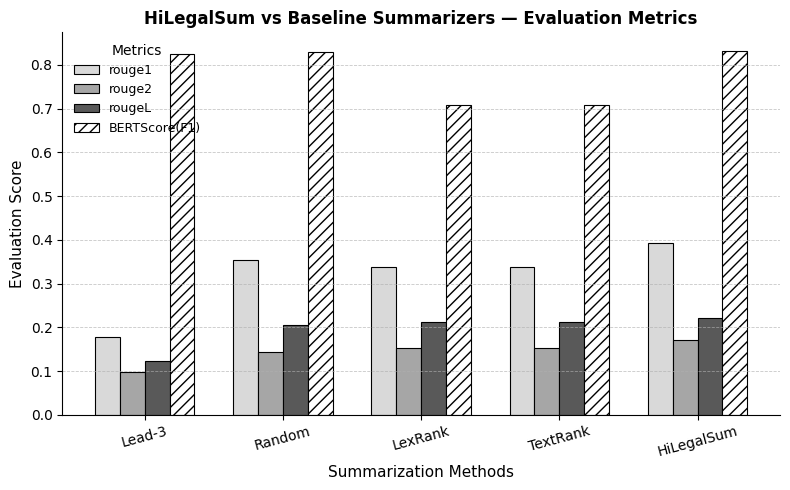

In [ ]:
# ============================================
# 📊 HiLegalSum vs Baseline Summarizers — IEEE Grayscale Style
# ============================================

import matplotlib.pyplot as plt
import numpy as np

# Use df_results from your earlier evaluation
metrics = ["rouge1", "rouge2", "rougeL", "BERTScore(F1)"]
models = df_results.index.tolist()

# Convert DataFrame to numeric array
values = df_results[metrics].values
x = np.arange(len(models))  # model positions
width = 0.18  # bar width

plt.figure(figsize=(8, 5))

# IEEE grayscale and pattern scheme
colors = ['#d9d9d9', '#a6a6a6', '#595959', 'white']
hatches = [None, None, None, '///']

# Plot each metric as a grouped bar
for i, metric in enumerate(metrics):
    plt.bar(
        x + i*width, values[:, i], width,
        label=metric,
        color=colors[i],
        hatch=hatches[i],
        edgecolor='black',
        linewidth=0.8
    )

# Title and labels (IEEE style)
plt.title("HiLegalSum vs Baseline Summarizers — Evaluation Metrics", fontsize=12, fontweight='bold')
plt.xlabel("Summarization Methods", fontsize=11)
plt.ylabel("Evaluation Score", fontsize=11)

# X-axis and legend
plt.xticks(x + width*1.5, models, rotation=15)
plt.legend(title="Metrics", fontsize=9, title_fontsize=10, loc='upper left', frameon=False)

# Gridlines and border adjustments
plt.grid(axis='y', linestyle='--', linewidth=0.6, alpha=0.7)
plt.tight_layout()
plt.box(True)

# IEEE-style border and clean background
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Display plot
plt.show()
